In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/linear regression/data sets/DailyDelhiClimateTest.csv")
df = pd.DataFrame(data)

In [2]:
x = df['meantemp'].values
y = df['humidity'].values

x_query = np.linspace(x.min(), x.max(), 100)
df.head()



,date,meantemp,humidity,wind_speed,meanpressure
0,2017/1/1,15.913043,85.869565,2.743478,59.000000
1,2017/1/2,18.500000,77.222222,2.894444,1018.277778
2,2017/1/3,17.111111,81.888889,4.016667,1018.333333
3,2017/1/4,18.700000,70.050000,4.545000,1015.700000
4,2017/1/5,18.388889,74.944444,3.300000,1014.333333


[83.11996454 -1.60258947]

mean square error: 95.25641212201262 std of y 18.984266697698267
root mean square error: 9.759939145405191
R-squared: 0.7356942771011625


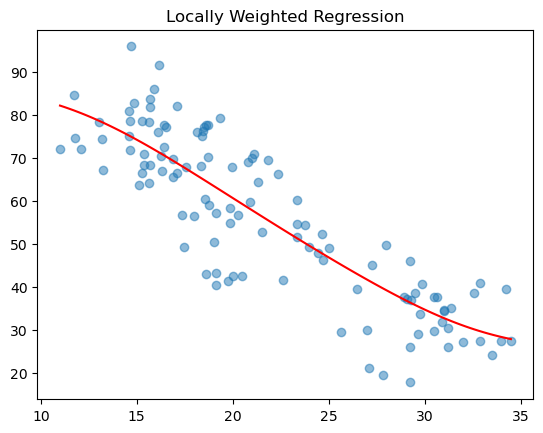

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = df['meantemp'].values
y = df['humidity'].values

x1 = x[:100]
# Add intercept term
X = np.column_stack((np.ones(len(x)), x))

# Query points (where we want predictions)
x_query = np.linspace(x.min(), x.max(), 100)

tau = 5  # bandwidth (tune this)

y_pred = []
i=0

xqr = [15,17,19]

for xq in x_query:
    # Compute weights
    w = np.exp(-(x - xq)**2 / (2 * tau**2))
    W = np.diag(w)

    # Compute theta
    theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

    # Prediction
    yq = theta[0] + theta[1] * xq
    y_pred.append(yq)

print(theta)
print()

ymean = np.mean(y)
ss_res = np.sum(error**2)
ss_tot = np.sum((y-ymean)**2)
r2 = 1- (ss_res/ss_tot)

print(f"mean square error: {mse}", f"std of y {y.std()}")
print(f"root mean square error: {rmse}")
print(f"R-squared: {r2}")
   
    
    

# Plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x_query, y_pred, color='red')
plt.title("Locally Weighted Regression")
plt.show()




In [12]:
print(theta)

[83.11996454 -1.60258947]


In [5]:
print(x)

[15.91304348 18.5        17.11111111 18.7        18.38888889 19.31818182
 14.70833333 15.68421053 14.57142857 12.11111111 11.         11.78947368
 13.23529412 13.2        16.43478261 14.65       11.72222222 13.04166667
 14.61904762 15.26315789 15.39130435 18.44       18.11764706 18.34782609
 21.         16.17857143 16.5        14.86363636 15.66666667 16.44444444
 16.125      15.25       17.09090909 15.63636364 18.7        18.63157895
 16.88888889 15.125      15.7        15.375      14.66666667 15.625
 16.25       16.33333333 16.875      17.57142857 20.25       21.3
 21.125      22.36363636 23.375      21.83333333 19.125      18.625
 19.125      19.         18.75       19.875      23.33333333 24.46153846
 23.75       20.5        19.125      19.75       20.         22.625
 21.54545455 20.78571429 19.9375     18.53333333 17.375      17.44444444
 18.         19.875      24.         20.9        24.69230769 24.66666667
 23.33333333 25.         27.25       28.         28.91666667 26.5
 29.1  

In [6]:
print(np.diag(-((x-xq)**2) / (2* 5**2)))

[[-0.19058601  0.          0.         ...  0.          0.
   0.        ]
 [ 0.         -0.005       0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -0.07135802 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -3.8642      0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -3.8503125
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  -3.38      ]]


In [15]:
theta2 = np.linalg.inv(X.T @ X) @ (X.T @ y)
print(theta2)

[112.09446593  -2.57154245]
